# Store Sales — Time Series Forecasting
## PyTorch Transformer Model

End-to-end demand forecasting pipeline using a custom Transformer architecture with categorical embeddings. Built for the Kaggle Store Sales competition.

# Load Data

In [1]:
from google.colab import drive
import pandas as pd
import os

drive.mount('/content/drive')
folder_path = '/content/drive/My Drive/IE7275/project/data'
file_path_holidays = os.path.join(folder_path, 'holidays_events.csv')
file_path_oil = os.path.join(folder_path, 'oil.csv')
file_path_stores = os.path.join(folder_path, 'stores.csv')
file_path_test = os.path.join(folder_path, 'test.csv')
file_path_train = os.path.join(folder_path, 'train.csv')
file_path_transactions = os.path.join(folder_path, 'transactions.csv')
file_path_sample_submission = os.path.join(folder_path, 'sample_submission.csv')

# Load all datasets
train = pd.read_csv(file_path_train)
test = pd.read_csv(file_path_test)
stores = pd.read_csv(file_path_stores)
oil = pd.read_csv(file_path_oil)
holidays = pd.read_csv(file_path_holidays)
sample_submission = pd.read_csv(file_path_sample_submission)


Mounted at /content/drive


# Data Preparation

## Check Missing Values

In [2]:
df = [train, test, stores, oil, holidays, sample_submission]
names = ['train', 'test', 'stores', 'oil', 'holidays', 'sample_submission']

for name, x in zip(names, df):
    y = x.isnull().sum()
    print(f"Dataset {name}:\n{y}\n")

Dataset train:
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

Dataset test:
id             0
date           0
store_nbr      0
family         0
onpromotion    0
dtype: int64

Dataset stores:
store_nbr    0
city         0
state        0
type         0
cluster      0
dtype: int64

Dataset oil:
date           0
dcoilwtico    43
dtype: int64

Dataset holidays:
date           0
type           0
locale         0
locale_name    0
description    0
transferred    0
dtype: int64

Dataset sample_submission:
id       0
sales    0
dtype: int64



In [3]:
# Handle missing values in oil dataset
# Forward fill first, then backward fill for any remaining nulls
oil['dcoilwtico'] = oil['dcoilwtico'].ffill().bfill()

# Verify no more missing values
print("Missing values in oil after handling:")
print(oil.isnull().sum())
print("\nOil dataset info:")
print(oil.info())

Missing values in oil after handling:
date          0
dcoilwtico    0
dtype: int64

Oil dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        1218 non-null   object 
 1   dcoilwtico  1218 non-null   float64
dtypes: float64(1), object(1)
memory usage: 19.2+ KB
None


## Outlier Handling

Sales Statistics:
count    3.000888e+06
mean     3.577757e+02
std      1.101998e+03
min      0.000000e+00
25%      0.000000e+00
50%      1.100000e+01
75%      1.958473e+02
max      1.247170e+05
Name: sales, dtype: float64

Negative sales count: 0
Zero sales count: 939130
Zero sales percentage: 31.30%

Outliers detected (IQR method): 447105 (14.90%)
Lower bound: -293.77
Upper bound: 489.62


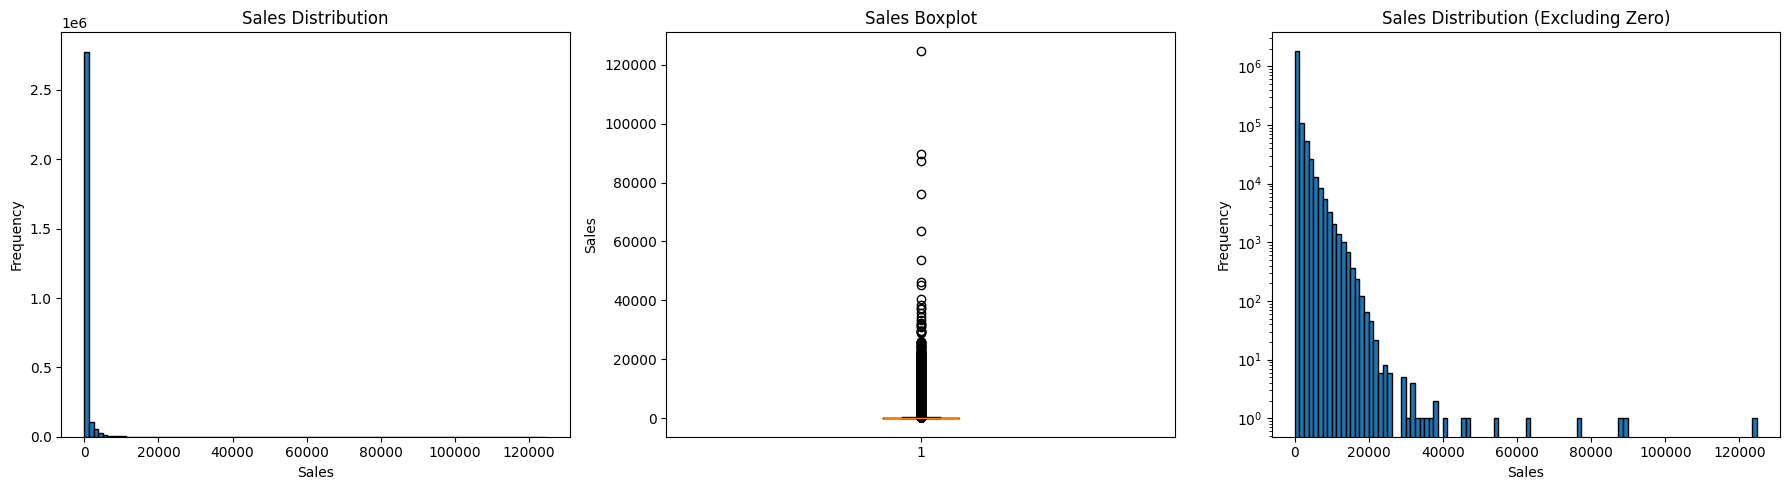


Top 10 highest sales records:
               date  store_nbr     family       sales  onpromotion
2163723  2016-05-02          2  GROCERY I  124717.000           59
2445984  2016-10-07         39      MEATS   89576.360            0
2144154  2016-04-21         20  GROCERY I   87438.516           53
2139699  2016-04-18         45  GROCERY I   76090.000           38
2153031  2016-04-26          2  GROCERY I   63434.000           30
2145045  2016-04-21         45  GROCERY I   53874.000           44
562596   2013-11-12         44  GROCERY I   46271.000            0
1257246  2014-12-08         35  GROCERY I   45361.000            3
1916586  2015-12-14         35  GROCERY I   40351.460            7
2760297  2017-04-02          9  GROCERY I   38422.625           73


In [4]:
# Check outliers in sales data
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Basic statistics
print("Sales Statistics:")
print(train['sales'].describe())
print(f"\nNegative sales count: {(train['sales'] < 0).sum()}")
print(f"Zero sales count: {(train['sales'] == 0).sum()}")
print(f"Zero sales percentage: {(train['sales'] == 0).sum() / len(train) * 100:.2f}%")

# Check outliers using IQR method
Q1 = train['sales'].quantile(0.25)
Q3 = train['sales'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = train[(train['sales'] < lower_bound) | (train['sales'] > upper_bound)]
print(f"\nOutliers detected (IQR method): {len(outliers)} ({len(outliers)/len(train)*100:.2f}%)")
print(f"Lower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(train['sales'], bins=100, edgecolor='black')
axes[0].set_title('Sales Distribution')
axes[0].set_xlabel('Sales')
axes[0].set_ylabel('Frequency')

# Boxplot
axes[1].boxplot(train['sales'])
axes[1].set_title('Sales Boxplot')
axes[1].set_ylabel('Sales')

# Log-scale histogram (for better view)
axes[2].hist(train[train['sales'] > 0]['sales'], bins=100, edgecolor='black')
axes[2].set_title('Sales Distribution (Excluding Zero)')
axes[2].set_xlabel('Sales')
axes[2].set_ylabel('Frequency')
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()

# Check sales by family (to see if outliers are category-specific)
print("\nTop 10 highest sales records:")
print(train.nlargest(10, 'sales')[['date', 'store_nbr', 'family', 'sales', 'onpromotion']])

Sales Statistics after Log Transform:
count    3.000888e+06
mean     2.926368e+00
std      2.695122e+00
min      0.000000e+00
25%      0.000000e+00
50%      2.484907e+00
75%      5.282428e+00
max      1.173381e+01
Name: sales, dtype: float64


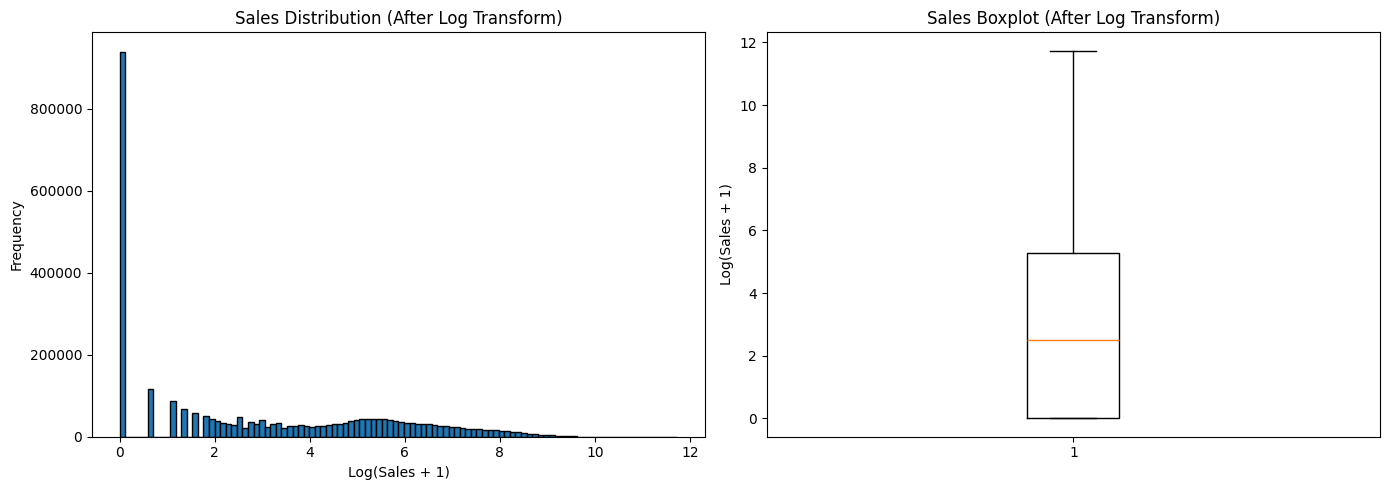


✓ Log transformation completed!
Note: When predicting, remember to inverse transform using np.expm1()


In [5]:
# Log transform for sales to handle outliers and skewness
train['sales'] = np.log1p(train['sales'])  # log1p = log(1 + x), handle zero values

# Verify the transformation
print("Sales Statistics after Log Transform:")
print(train['sales'].describe())

# Visualize the transformed distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram after transform
axes[0].hist(train['sales'], bins=100, edgecolor='black')
axes[0].set_title('Sales Distribution (After Log Transform)')
axes[0].set_xlabel('Log(Sales + 1)')
axes[0].set_ylabel('Frequency')

# Boxplot after transform
axes[1].boxplot(train['sales'])
axes[1].set_title('Sales Boxplot (After Log Transform)')
axes[1].set_ylabel('Log(Sales + 1)')

plt.tight_layout()
plt.show()

print("\n✓ Log transformation completed!")
print("Note: When predicting, remember to inverse transform using np.expm1()")

In [6]:
# ===== PREPARATION =====

# 1. Add flag to distinguish train and test
train['is_train'] = 1
test['is_train'] = 0

# 2. Concatenate train and test
# Note: test doesn't have 'sales' column, so we'll add it as NaN
test['sales'] = np.nan

# Combine both datasets
df = pd.concat([train, test], axis=0, ignore_index=True)

print("Combined dataset shape:", df.shape)
print("\nTrain samples:", df[df['is_train'] == 1].shape[0])
print("Test samples:", df[df['is_train'] == 0].shape[0])

# 3. Convert date to datetime
df['date'] = pd.to_datetime(df['date'])
oil['date'] = pd.to_datetime(oil['date'])
holidays['date'] = pd.to_datetime(holidays['date'])

print("\n✓ Date columns converted to datetime")

# 4. Check the date range
print("\nDate range in combined data:")
print(f"Start: {df['date'].min()}")
print(f"End: {df['date'].max()}")

print("\nDate range in oil data:")
print(f"Start: {oil['date'].min()}")
print(f"End: {oil['date'].max()}")

print("\nDate range in holidays data:")
print(f"Start: {holidays['date'].min()}")
print(f"End: {holidays['date'].max()}")

# 5. Verify the structure
print("\nCombined dataframe info:")
print(df.info())
print("\nFirst few rows:")
print(df.head())
print("\nLast few rows (should be test data):")
print(df.tail())

Combined dataset shape: (3029400, 7)

Train samples: 3000888
Test samples: 28512

✓ Date columns converted to datetime

Date range in combined data:
Start: 2013-01-01 00:00:00
End: 2017-08-31 00:00:00

Date range in oil data:
Start: 2013-01-01 00:00:00
End: 2017-08-31 00:00:00

Date range in holidays data:
Start: 2012-03-02 00:00:00
End: 2017-12-26 00:00:00

Combined dataframe info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3029400 entries, 0 to 3029399
Data columns (total 7 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
 6   is_train     int64         
dtypes: datetime64[ns](1), float64(1), int64(4), object(1)
memory usage: 161.8+ MB
None

First few rows:
   id       date  store_nbr      family  sales  onpromotion  is_train
0   0 2013-01-01          1  A

In [7]:
# ===== MERGING WITH OTHER DATASETS =====

# 1. Merge with stores (by store_nbr)
df = df.merge(stores, on='store_nbr', how='left')
print("After merging with stores:")
print(f"Shape: {df.shape}")
print(f"New columns: {['city', 'state', 'type', 'cluster']}")
print(f"Missing values:\n{df[['city', 'state', 'type', 'cluster']].isnull().sum()}\n")

# 2. Merge with oil (by date)
df = df.merge(oil, on='date', how='left')
print("After merging with oil:")
print(f"Shape: {df.shape}")
print(f"New columns: ['dcoilwtico']")
print(f"Missing values in dcoilwtico: {df['dcoilwtico'].isnull().sum()}")

# Handle missing oil prices (in case there are dates not in oil dataset)
df['dcoilwtico'] = df['dcoilwtico'].ffill().bfill()
print(f"After ffill/bfill: {df['dcoilwtico'].isnull().sum()} missing values\n")

# 3. Merge with holidays (by date)
# Create a flag for holidays instead of merging all columns
# This prevents duplicates and is more efficient
holidays_dates = holidays[['date']].drop_duplicates()
holidays_dates['is_holiday'] = 1

df = df.merge(holidays_dates, on='date', how='left')
df['is_holiday'] = df['is_holiday'].fillna(0).astype(int)

print("After merging with holidays:")
print(f"Shape: {df.shape}")
print(f"New columns: ['is_holiday']")
print(f"Holiday count: {df['is_holiday'].sum()}")
print(f"Holiday percentage: {df['is_holiday'].mean() * 100:.2f}%\n")

# 4. Verify final merged dataset
print("="*50)
print("FINAL MERGED DATASET INFO:")
print("="*50)
print(f"Total rows: {len(df)}")
print(f"Total columns: {len(df.columns)}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nMissing values per column:")
print(df.isnull().sum())
print(f"\nDataframe info:")
print(df.info())

After merging with stores:
Shape: (3029400, 11)
New columns: ['city', 'state', 'type', 'cluster']
Missing values:
city       0
state      0
type       0
cluster    0
dtype: int64

After merging with oil:
Shape: (3029400, 12)
New columns: ['dcoilwtico']
Missing values in dcoilwtico: 864270
After ffill/bfill: 0 missing values

After merging with holidays:
Shape: (3029400, 13)
New columns: ['is_holiday']
Holiday count: 450846
Holiday percentage: 14.88%

FINAL MERGED DATASET INFO:
Total rows: 3029400
Total columns: 13

Columns: ['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'is_train', 'city', 'state', 'type', 'cluster', 'dcoilwtico', 'is_holiday']

Missing values per column:
id                 0
date               0
store_nbr          0
family             0
sales          28512
onpromotion        0
is_train           0
city               0
state              0
type               0
cluster            0
dcoilwtico         0
is_holiday         0
dtype: int64

Dataframe info:
<

In [8]:
# ===== EXTRACT DATE FEATURES =====

# 1. Basic date components
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.dayofweek  # Monday=0, Sunday=6
df['day_of_year'] = df['date'].dt.dayofyear
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
df['quarter'] = df['date'].dt.quarter

print("Basic date features extracted:")
print(['year', 'month', 'day', 'day_of_week', 'day_of_year', 'week_of_year', 'quarter'])

# 2. Special date flags
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)  # Saturday=5, Sunday=6
df['is_month_start'] = df['date'].dt.is_month_start.astype(int)
df['is_month_end'] = df['date'].dt.is_month_end.astype(int)
df['is_quarter_start'] = df['date'].dt.is_quarter_start.astype(int)
df['is_quarter_end'] = df['date'].dt.is_quarter_end.astype(int)
df['is_year_start'] = df['date'].dt.is_year_start.astype(int)
df['is_year_end'] = df['date'].dt.is_year_end.astype(int)

print("\nSpecial date flags created:")
print(['is_weekend', 'is_month_start', 'is_month_end', 'is_quarter_start', 'is_quarter_end', 'is_year_start', 'is_year_end'])

# 3. Days to payday (assume payday is 15th and end of month)
df['days_to_payday'] = df['day'].apply(lambda x: min(abs(x - 15), abs(x - 31)))

print("\nPayday feature created: 'days_to_payday'")

# 4. Verify all new features
print("\n" + "="*50)
print("DATE FEATURES SUMMARY:")
print("="*50)
print(f"Total columns now: {len(df.columns)}")
print(f"\nAll columns: {list(df.columns)}")

# Show sample of date features
print("\nSample of date features:")
date_features = ['date', 'year', 'month', 'day', 'day_of_week', 'week_of_year',
                 'is_weekend', 'is_holiday', 'is_month_end', 'days_to_payday']
print(df[date_features].head(10))

# Check value distributions
print("\nValue distributions:")
print(f"Weekends: {df['is_weekend'].sum()} ({df['is_weekend'].mean()*100:.2f}%)")
print(f"Holidays: {df['is_holiday'].sum()} ({df['is_holiday'].mean()*100:.2f}%)")
print(f"Month starts: {df['is_month_start'].sum()}")
print(f"Month ends: {df['is_month_end'].sum()}")

print("\n✓ Date feature extraction completed!")

Basic date features extracted:
['year', 'month', 'day', 'day_of_week', 'day_of_year', 'week_of_year', 'quarter']

Special date flags created:
['is_weekend', 'is_month_start', 'is_month_end', 'is_quarter_start', 'is_quarter_end', 'is_year_start', 'is_year_end']

Payday feature created: 'days_to_payday'

DATE FEATURES SUMMARY:
Total columns now: 28

All columns: ['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'is_train', 'city', 'state', 'type', 'cluster', 'dcoilwtico', 'is_holiday', 'year', 'month', 'day', 'day_of_week', 'day_of_year', 'week_of_year', 'quarter', 'is_weekend', 'is_month_start', 'is_month_end', 'is_quarter_start', 'is_quarter_end', 'is_year_start', 'is_year_end', 'days_to_payday']

Sample of date features:
        date  year  month  day  day_of_week  week_of_year  is_weekend  \
0 2013-01-01  2013      1    1            1             1           0   
1 2013-01-01  2013      1    1            1             1           0   
2 2013-01-01  2013      1    1       

In [9]:
# ===== ENCODE CATEGORICAL VARIABLES =====

from sklearn.preprocessing import LabelEncoder

# Make a copy of categorical columns for reference
categorical_cols = ['family', 'city', 'state', 'type', 'store_nbr', 'cluster', 'year']

print("Categorical columns to encode:", categorical_cols)
print("\nUnique values per column:")
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")

# Initialize label encoders dictionary to store encoders (useful for future use)
label_encoders = {}

# 1. Encode each categorical column
for col in categorical_cols:
    le = LabelEncoder()
    df[col + '_encoded'] = le.fit_transform(df[col])
    label_encoders[col] = le

    print(f"\n✓ Encoded '{col}' -> '{col}_encoded'")
    print(f"  Sample mapping: {dict(list(zip(le.classes_[:5], range(5))))}")

# 2. Verify encoding
print("\n" + "="*50)
print("ENCODING SUMMARY:")
print("="*50)

# Show before and after for a sample
print("\nSample - Original vs Encoded:")
sample_cols = ['family', 'family_encoded',
               'city', 'city_encoded',
               'type', 'type_encoded',
               'store_nbr', 'store_nbr_encoded',
               'cluster', 'cluster_encoded',
               'year', 'year_encoded'
               ]
print(df[sample_cols].head(10))

# Check if any missing values in encoded columns
encoded_cols = [col + '_encoded' for col in categorical_cols]
print(f"\nMissing values in encoded columns:")
print(df[encoded_cols].isnull().sum())

# 3. Optional: Drop original categorical columns to save memory
# (Keep them for now, we can drop later if needed)
print(f"\n✓ Categorical encoding completed!")
print(f"New encoded columns: {encoded_cols}")
print(f"Total columns now: {len(df.columns)}")

# Show all columns
print(f"\nAll columns: {list(df.columns)}")

Categorical columns to encode: ['family', 'city', 'state', 'type', 'store_nbr', 'cluster', 'year']

Unique values per column:
family: 33 unique values
city: 22 unique values
state: 16 unique values
type: 5 unique values
store_nbr: 54 unique values
cluster: 17 unique values
year: 5 unique values

✓ Encoded 'family' -> 'family_encoded'
  Sample mapping: {'AUTOMOTIVE': 0, 'BABY CARE': 1, 'BEAUTY': 2, 'BEVERAGES': 3, 'BOOKS': 4}

✓ Encoded 'city' -> 'city_encoded'
  Sample mapping: {'Ambato': 0, 'Babahoyo': 1, 'Cayambe': 2, 'Cuenca': 3, 'Daule': 4}

✓ Encoded 'state' -> 'state_encoded'
  Sample mapping: {'Azuay': 0, 'Bolivar': 1, 'Chimborazo': 2, 'Cotopaxi': 3, 'El Oro': 4}

✓ Encoded 'type' -> 'type_encoded'
  Sample mapping: {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}

✓ Encoded 'store_nbr' -> 'store_nbr_encoded'
  Sample mapping: {np.int64(1): 0, np.int64(2): 1, np.int64(3): 2, np.int64(4): 3, np.int64(5): 4}

✓ Encoded 'cluster' -> 'cluster_encoded'
  Sample mapping: {np.int64(1): 0, np.i

In [10]:
# ===== LAG FEATURES & ROLLING STATISTICS =====
# WARNING: This process might take 5-15 minutes due to large dataset!

print("Starting Lag & Rolling Features creation...")
print("This might take several minutes, please wait...\n")

# 1. Sort data by store_nbr, family, and date (CRUCIAL!)
df = df.sort_values(['store_nbr', 'family', 'date']).reset_index(drop=True)
print("✓ Data sorted by store_nbr, family, and date")

# 2. Create a copy of sales for train only (to avoid data leakage)
# We'll use this to create features, then apply to both train and test
df['sales_for_features'] = df['sales'].copy()
# Set test sales to NaN so they don't leak into lag/rolling calculations
df.loc[df['is_train'] == 0, 'sales_for_features'] = np.nan

print("✓ Sales copied for feature creation (test sales set to NaN)")

# 3. Create Lag Features
print("\nCreating lag features...")
lag_days = [7, 14, 28]

for lag in lag_days:
    df[f'sales_lag_{lag}'] = df.groupby(['store_nbr', 'family'])['sales_for_features'].shift(lag)
    print(f"  ✓ sales_lag_{lag} created")

# 4. Create Rolling Mean Features
print("\nCreating rolling mean features...")
rolling_windows = [7, 14, 16, 28]

for window in rolling_windows:
    df[f'sales_rolling_mean_{window}'] = df.groupby(['store_nbr', 'family'])['sales_for_features'].transform(
        lambda x: x.shift(1).rolling(window=window, min_periods=1).mean()
    )
    print(f"  ✓ sales_rolling_mean_{window} created")

# 5. Create Rolling Std Features (volatility measure)
print("\nCreating rolling std features...")
df['sales_rolling_std_7'] = df.groupby(['store_nbr', 'family'])['sales_for_features'].transform(
    lambda x: x.shift(1).rolling(window=7, min_periods=1).std()
)
print("  ✓ sales_rolling_std_7 created")

# 6. Create Promotion Rolling Sum (total promo days in last 7 days)
print("\nCreating promotion rolling features...")
df['promo_rolling_sum_7'] = df.groupby(['store_nbr', 'family'])['onpromotion'].transform(
    lambda x: x.shift(1).rolling(window=7, min_periods=1).sum()
)
print("  ✓ promo_rolling_sum_7 created")

# 7. Drop the temporary column
df = df.drop('sales_for_features', axis=1)

# 8. Check for missing values in new features
print("\n" + "="*50)
print("LAG & ROLLING FEATURES SUMMARY:")
print("="*50)

lag_rolling_cols = [f'sales_lag_{lag}' for lag in lag_days] + \
                   [f'sales_rolling_mean_{window}' for window in rolling_windows] + \
                   ['sales_rolling_std_7', 'promo_rolling_sum_7']

print(f"\nNew features created: {len(lag_rolling_cols)}")
print(f"Features: {lag_rolling_cols}")

print(f"\nMissing values in new features:")
print(df[lag_rolling_cols].isnull().sum())

print(f"\nMissing value percentages:")
for col in lag_rolling_cols:
    missing_pct = df[col].isnull().sum() / len(df) * 100
    print(f"  {col}: {missing_pct:.2f}%")

# 9. Show sample of features
print("\nSample of lag & rolling features:")
sample_cols = ['date', 'store_nbr', 'family', 'sales', 'sales_lag_7',
               'sales_rolling_mean_7', 'sales_rolling_std_7', 'promo_rolling_sum_7']
print(df[df['is_train'] == 1][sample_cols].head(30))

print("\n✓ Lag & Rolling features creation completed!")
print(f"Total columns now: {len(df.columns)}")

Starting Lag & Rolling Features creation...
This might take several minutes, please wait...

✓ Data sorted by store_nbr, family, and date
✓ Sales copied for feature creation (test sales set to NaN)

Creating lag features...
  ✓ sales_lag_7 created
  ✓ sales_lag_14 created
  ✓ sales_lag_28 created

Creating rolling mean features...
  ✓ sales_rolling_mean_7 created
  ✓ sales_rolling_mean_14 created
  ✓ sales_rolling_mean_16 created
  ✓ sales_rolling_mean_28 created

Creating rolling std features...
  ✓ sales_rolling_std_7 created

Creating promotion rolling features...
  ✓ promo_rolling_sum_7 created

LAG & ROLLING FEATURES SUMMARY:

New features created: 9
Features: ['sales_lag_7', 'sales_lag_14', 'sales_lag_28', 'sales_rolling_mean_7', 'sales_rolling_mean_14', 'sales_rolling_mean_16', 'sales_rolling_mean_28', 'sales_rolling_std_7', 'promo_rolling_sum_7']

Missing values in new features:
sales_lag_7              28512
sales_lag_14             28512
sales_lag_28             49896
sales_r

In [11]:
# ===== DIFFERENCE FEATURES =====
# Define all reference columns for difference calculation
ref_cols = [
    'sales_lag_7', 'sales_lag_14', 'sales_lag_28',
    'sales_rolling_mean_7', 'sales_rolling_mean_14',
    'sales_rolling_mean_16', 'sales_rolling_mean_28'
]

# Batch generate difference columns: current_sales - reference_value
for col in ref_cols:
    new_col_name = f"diff_{col}"
    df[new_col_name] = df['sales'] - df[col]
    print(f"Feature created: {new_col_name}")

# Special handling for rolling_std_7: normally computes deviation of sales from mean
# divided by std (similar to Z-Score). Use the line below for simple subtraction:
#df['diff_sales_rolling_std_7'] = df['sales'] - df['sales_rolling_std_7']

# Fill missing values in new difference columns
diff_cols = [f"diff_{col}" for col in ref_cols]
df[diff_cols] = df[diff_cols].fillna(0)

# Result preview
print(df[['date', 'sales'] + diff_cols].head())

Feature created: diff_sales_lag_7
Feature created: diff_sales_lag_14
Feature created: diff_sales_lag_28
Feature created: diff_sales_rolling_mean_7
Feature created: diff_sales_rolling_mean_14
Feature created: diff_sales_rolling_mean_16
Feature created: diff_sales_rolling_mean_28
        date     sales  diff_sales_lag_7  diff_sales_lag_14  \
0 2013-01-01  0.000000               0.0                0.0   
1 2013-01-02  1.098612               0.0                0.0   
2 2013-01-03  1.386294               0.0                0.0   
3 2013-01-04  1.386294               0.0                0.0   
4 2013-01-05  1.791759               0.0                0.0   

   diff_sales_lag_28  diff_sales_rolling_mean_7  diff_sales_rolling_mean_14  \
0                0.0                   0.000000                    0.000000   
1                0.0                   1.098612                    1.098612   
2                0.0                   0.836988                    0.836988   
3                0.0      

In [15]:
# ===== HANDLE MISSING VALUES FROM NEW FEATURES =====

print("="*50)
print("STEP 3: HANDLING MISSING VALUES")
print("="*50)

# 1. Check missing values
print("\nMissing values before handling:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# 2. Fill missing values in lag and rolling features
# Strategy: Fill with 0 (representing no sales history)
lag_rolling_cols = [col for col in df.columns if 'lag' in col or 'rolling' in col]

print(f"\nFilling missing values in {len(lag_rolling_cols)} lag/rolling features with 0...")
for col in lag_rolling_cols:
    df[col] = df[col].fillna(method='ffill')

print("✓ Missing values filled")

# 3. Verify no missing values (except sales in test which is expected)
print("\nMissing values after handling:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\n✓ Step 3 completed!")

# ===== STEP 4: SPLIT TRAIN & TEST =====

print("\n" + "="*50)
print("STEP 4: SPLIT TRAIN & TEST")
print("="*50)

# 1. Separate train and test
train_df = df[df['is_train'] == 1].copy()
test_df = df[df['is_train'] == 0].copy()

print(f"\nTrain shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

# 2. Define features to drop
cols_to_drop = ['is_train', 'date', 'id']  # Drop flags and non-feature columns
# Also drop original categorical columns (we have encoded versions)
categorical_original = ['family', 'city', 'state', 'type', 'store_nbr', 'cluster', 'year']
cols_to_drop.extend(categorical_original)
lag_features = ['sales_lag_7', 'sales_lag_14', 'sales_lag_28', 'sales_rolling_mean_7', 'sales_rolling_mean_14',
    'sales_rolling_mean_16', 'sales_rolling_mean_28']
cols_to_drop.extend(lag_features)

print(f"\nColumns to drop: {cols_to_drop}")

# 3. Prepare feature columns (all except sales and cols_to_drop)
feature_cols = [col for col in train_df.columns if col not in cols_to_drop + ['sales']]

print(f"\nTotal feature columns: {len(feature_cols)}")
print(f"Feature columns: {feature_cols}")

# 4. Create X_train, y_train, X_test
X_train = train_df[feature_cols].copy()
y_train = train_df['sales'].copy()  # Already log-transformed
X_test = test_df[feature_cols].copy()

# Keep id and date for submission later
test_id = test_df['id'].copy()
test_date = test_df['date'].copy()

print(f"\nX_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")

# 5. Verify no missing values in features
print(f"\nMissing values in X_train: {X_train.isnull().sum().sum()}")
print(f"Missing values in X_test: {X_test.isnull().sum().sum()}")
print(f"Missing values in y_train: {y_train.isnull().sum()}")

# 6. Show feature summary
print("\n" + "="*50)
print("FEATURE SUMMARY:")
print("="*50)
print(f"Total features: {len(feature_cols)}")
print(f"\nFeature types:")
print(X_train.dtypes.value_counts())

print("\n✓ Step 4 completed!")
print("\nReady for Model Training!")

# Display first few rows of train features
print("\nSample X_train:")
print(X_train.head())
print("\nSample y_train (log-transformed sales):")
print(y_train.head())

STEP 3: HANDLING MISSING VALUES

Missing values before handling:
sales                    28512
sales_lag_7                  7
sales_lag_14                14
sales_lag_28                28
sales_rolling_mean_7         1
sales_rolling_mean_14        1
sales_rolling_mean_16        1
sales_rolling_mean_28        1
sales_rolling_std_7          2
promo_rolling_sum_7          1
dtype: int64

Filling missing values in 16 lag/rolling features with 0...


/tmp/ipykernel_6963/3698615295.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[col] = df[col].fillna(method='ffill')


✓ Missing values filled

Missing values after handling:
sales                    28512
sales_lag_7                  7
sales_lag_14                14
sales_lag_28                28
sales_rolling_mean_7         1
sales_rolling_mean_14        1
sales_rolling_mean_16        1
sales_rolling_mean_28        1
sales_rolling_std_7          2
promo_rolling_sum_7          1
dtype: int64

✓ Step 3 completed!

STEP 4: SPLIT TRAIN & TEST

Train shape: (3000888, 51)
Test shape: (28512, 51)

Columns to drop: ['is_train', 'date', 'id', 'family', 'city', 'state', 'type', 'store_nbr', 'cluster', 'year', 'sales_lag_7', 'sales_lag_14', 'sales_lag_28', 'sales_rolling_mean_7', 'sales_rolling_mean_14', 'sales_rolling_mean_16', 'sales_rolling_mean_28']

Total feature columns: 33
Feature columns: ['onpromotion', 'dcoilwtico', 'is_holiday', 'month', 'day', 'day_of_week', 'day_of_year', 'week_of_year', 'quarter', 'is_weekend', 'is_month_start', 'is_month_end', 'is_quarter_start', 'is_quarter_end', 'is_year_start'

In [13]:
X_train.head()

,onpromotion,dcoilwtico,is_holiday,month,day,day_of_week,day_of_year,week_of_year,quarter,is_weekend,...,year_encoded,sales_rolling_std_7,promo_rolling_sum_7,diff_sales_lag_7,diff_sales_lag_14,diff_sales_lag_28,diff_sales_rolling_mean_7,diff_sales_rolling_mean_14,diff_sales_rolling_mean_16,diff_sales_rolling_mean_28
0,0,93.14,1,1,1,1,1,1,1,0,...,0,NaN,NaN,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
1,0,93.14,0,1,2,2,2,1,1,0,...,0,NaN,0.0,0.0,0.0,0.0,1.098612,1.098612,1.098612,1.098612
2,0,92.97,0,1,3,3,3,1,1,0,...,0,0.776836,0.0,0.0,0.0,0.0,0.836988,0.836988,0.836988,0.836988
3,0,93.12,0,1,4,4,4,1,1,0,...,0,0.731610,0.0,0.0,0.0,0.0,0.557992,0.557992,0.557992,0.557992
4,0,93.12,1,1,5,5,5,1,1,1,...,0,0.659299,0.0,0.0,0.0,0.0,0.823959,0.823959,0.823959,0.823959


In [16]:
# ===== SPLIT TRAIN & VALIDATION =====
# 1. TIME-BASED TRAIN-VALIDATION SPLIT
# Use last 15 days of train data as validation
print("\n1. Creating Time-Based Train-Validation Split...")

# Get unique dates and sort
unique_dates = sorted(train_df['date'].unique())
print(f"Total unique dates in train: {len(unique_dates)}")
print(f"Date range: {unique_dates[0]} to {unique_dates[-1]}")

# Split: last 15 days for validation
val_days = 15
val_start_date = unique_dates[-val_days]

print(f"\nValidation start date: {val_start_date}")
print(f"Validation will use last {val_days} days")

# Create train and validation sets
train_mask = train_df['date'] < val_start_date
val_mask = train_df['date'] >= val_start_date

X_tr = X_train[train_mask]
y_tr = y_train[train_mask]
X_val = X_train[val_mask]
y_val = y_train[val_mask]

print(f"\nTrain set: {X_tr.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Train ratio: {X_tr.shape[0]/X_train.shape[0]*100:.2f}%")
print(f"Val ratio: {X_val.shape[0]/X_train.shape[0]*100:.2f}%")


1. Creating Time-Based Train-Validation Split...
Total unique dates in train: 1684
Date range: 2013-01-01 00:00:00 to 2017-08-15 00:00:00

Validation start date: 2017-08-01 00:00:00
Validation will use last 15 days

Train set: 2974158 samples
Validation set: 26730 samples
Train ratio: 99.11%
Val ratio: 0.89%


# Random Forest

Training Random Forest to evaluate feature importance, please wait...


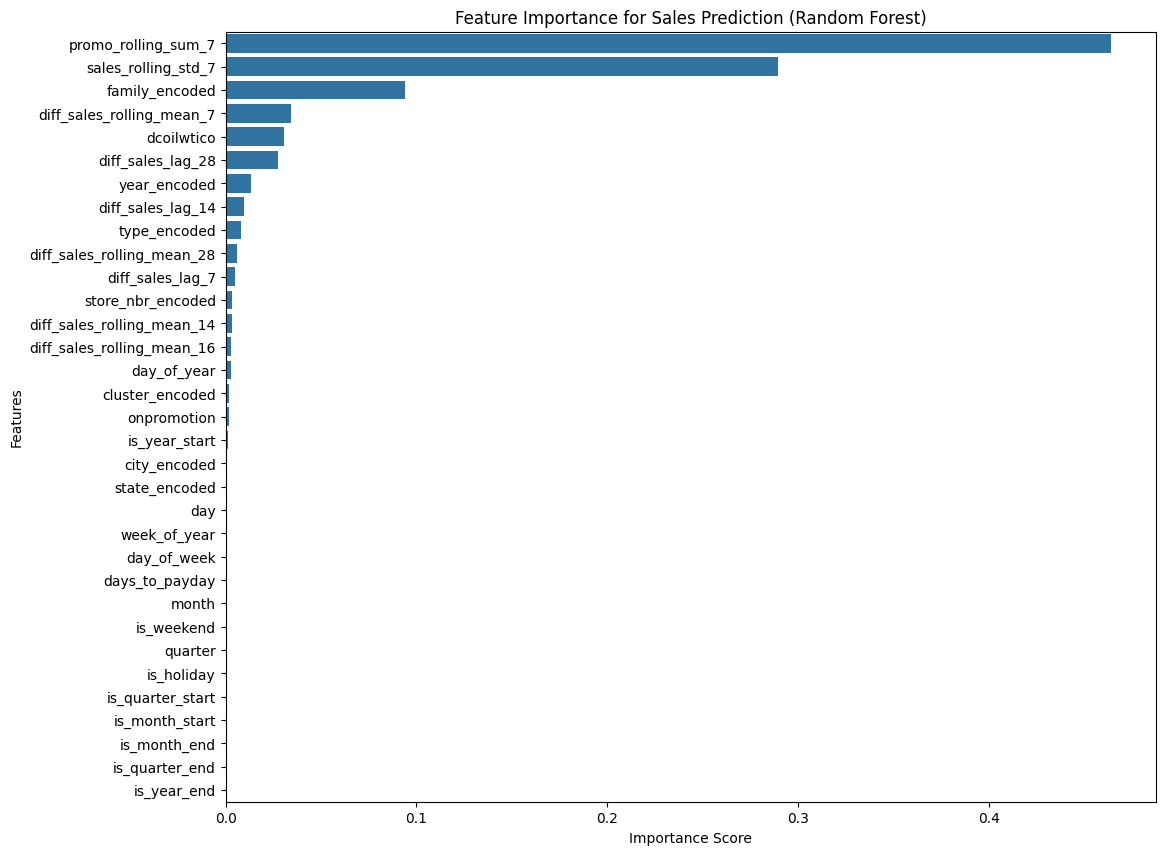


Feature importance ranking:
                       Feature  Importance
25         promo_rolling_sum_7    0.464173
24         sales_rolling_std_7    0.289593
17              family_encoded    0.093794
29   diff_sales_rolling_mean_7    0.034272
1                   dcoilwtico    0.030576
28           diff_sales_lag_28    0.027641
23                year_encoded    0.013122
27           diff_sales_lag_14    0.009436
20                type_encoded    0.008055
32  diff_sales_rolling_mean_28    0.005950
26            diff_sales_lag_7    0.004765
21           store_nbr_encoded    0.003235
30  diff_sales_rolling_mean_14    0.003072
31  diff_sales_rolling_mean_16    0.002722
6                  day_of_year    0.002692
22             cluster_encoded    0.001624
0                  onpromotion    0.001589
14               is_year_start    0.001240
18                city_encoded    0.000720
19               state_encoded    0.000686
4                          day    0.000240
7                 week_of

In [17]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. For speed, sample 10-20% of data for feature importance analysis.
# 3M rows is too large for RF training; use a sample to reflect importance trends.
X_sample = X_train.sample(frac=0.1, random_state=42)
y_sample = y_train.loc[X_sample.index]

# 2. Handle residual NaN values (Random Forest does not accept NaN input)
X_sample = X_sample.fillna(0)

# 3. Initialize and train Random Forest
# n_estimators: number of trees (100 is sufficient for trend analysis)
# max_depth: limiting depth prevents overfitting to local details and speeds training
# n_jobs=-1: use all CPU cores in parallel
print("Training Random Forest to evaluate feature importance, please wait...")
rf = RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42)
rf.fit(X_sample, y_sample)

# 4. Extract feature importance
importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 5. Visualize
plt.figure(figsize=(12, 10))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance for Sales Prediction (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

# Print values
print("\nFeature importance ranking:")
print(feature_importance_df)

In [18]:
import os

# 1. Define save path (based on your previously mounted IE7275 project path)
output_path = '/content/drive/My Drive/IE7275/project/output'
if not os.path.exists(output_path):
    os.makedirs(output_path)

# 2. Set file name
file_name = 'rf_feature_importance.csv'
full_save_path = os.path.join(output_path, file_name)

# 3. Save results to CSV
# index=False: do not save row index (cleaner output)
feature_importance_df.to_csv(full_save_path, index=False)

print(f"Feature importance results successfully saved to Drive:\n{full_save_path}")

Feature importance results successfully saved to Drive:
/content/drive/My Drive/IE7275/project/output/rf_feature_importance.csv


In [20]:
new_drop_col = ['is_month_end', 'is_quarter_end', 'is_year_end']
cols_to_drop.extend(new_drop_col)
# 1. Prepare feature columns (all except sales and cols_to_drop)
feature_cols = [col for col in train_df.columns if col not in cols_to_drop + ['sales']]

print(f"\nTotal feature columns: {len(feature_cols)}")
print(f"Feature columns: {feature_cols}")

# 2. Create X_train, y_train, X_test
X_train = train_df[feature_cols].copy()
y_train = train_df['sales'].copy()  # Already log-transformed
X_test = test_df[feature_cols].copy()

# 3. Keep id and date for submission later
test_id = test_df['id'].copy()
test_date = test_df['date'].copy()

print(f"\nX_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")

# 4. Verify no missing values in features
print(f"\nMissing values in X_train: {X_train.isnull().sum().sum()}")
print(f"Missing values in X_test: {X_test.isnull().sum().sum()}")
print(f"Missing values in y_train: {y_train.isnull().sum()}")

# 5. Show feature summary
print("\n" + "="*50)
print("FEATURE SUMMARY:")
print("="*50)
print(f"Total features: {len(feature_cols)}")
print(f"\nFeature types:")
print(X_train.dtypes.value_counts())

print("\n✓ Step 4 completed!")
print("\nReady for Model Training!")

# 6. Display first few rows of train features
print("\nSample X_train:")
print(X_train.head())
print("\nSample y_train (log-transformed sales):")
print(y_train.head())


Total feature columns: 30
Feature columns: ['onpromotion', 'dcoilwtico', 'is_holiday', 'month', 'day', 'day_of_week', 'day_of_year', 'week_of_year', 'quarter', 'is_weekend', 'is_month_start', 'is_quarter_start', 'is_year_start', 'days_to_payday', 'family_encoded', 'city_encoded', 'state_encoded', 'type_encoded', 'store_nbr_encoded', 'cluster_encoded', 'year_encoded', 'sales_rolling_std_7', 'promo_rolling_sum_7', 'diff_sales_lag_7', 'diff_sales_lag_14', 'diff_sales_lag_28', 'diff_sales_rolling_mean_7', 'diff_sales_rolling_mean_14', 'diff_sales_rolling_mean_16', 'diff_sales_rolling_mean_28']

X_train shape: (3000888, 30)
y_train shape: (3000888,)
X_test shape: (28512, 30)

Missing values in X_train: 3
Missing values in X_test: 0
Missing values in y_train: 0

FEATURE SUMMARY:
Total features: 30

Feature types:
int64      15
float64    10
int32       5
Name: count, dtype: int64

✓ Step 4 completed!

Ready for Model Training!

Sample X_train:
   onpromotion  dcoilwtico  is_holiday  month  

In [21]:
# ===== SPLIT TRAIN & VALIDATION AGAIN=====
# 1. TIME-BASED TRAIN-VALIDATION SPLIT
# Use last 15 days of train data as validation
print("\n1. Creating Time-Based Train-Validation Split...")

# Get unique dates and sort
unique_dates = sorted(train_df['date'].unique())
print(f"Total unique dates in train: {len(unique_dates)}")
print(f"Date range: {unique_dates[0]} to {unique_dates[-1]}")

# Split: last 15 days for validation
val_days = 15
val_start_date = unique_dates[-val_days]

print(f"\nValidation start date: {val_start_date}")
print(f"Validation will use last {val_days} days")

# Create train and validation sets
train_mask = train_df['date'] < val_start_date
val_mask = train_df['date'] >= val_start_date

X_tr = X_train[train_mask]
y_tr = y_train[train_mask]
X_val = X_train[val_mask]
y_val = y_train[val_mask]

print(f"\nTrain set: {X_tr.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Train ratio: {X_tr.shape[0]/X_train.shape[0]*100:.2f}%")
print(f"Val ratio: {X_val.shape[0]/X_train.shape[0]*100:.2f}%")


1. Creating Time-Based Train-Validation Split...
Total unique dates in train: 1684
Date range: 2013-01-01 00:00:00 to 2017-08-15 00:00:00

Validation start date: 2017-08-01 00:00:00
Validation will use last 15 days

Train set: 2974158 samples
Validation set: 26730 samples
Train ratio: 99.11%
Val ratio: 0.89%


In [22]:
# ===== STANDARDSCALER FOR NUMERIC FEATURES =====
from sklearn.preprocessing import StandardScaler

# Identify numeric columns
categorical_cols = [
    'family_encoded', 'city_encoded', 'state_encoded', 'type_encoded',
    'store_nbr_encoded', 'cluster_encoded', 'onpromotion_encoded', # consider label encoding or binning for promotion
    'day_of_week', 'month', 'year_encoded', 'is_weekend', 'is_holiday',
    'is_year_start', 'days_to_payday', 'is_month_start', 'is_quarter_start'
]
num_cols = [col for col in feature_cols if col not in categorical_cols]

scaler = StandardScaler()
# Fit scaler on training data only to prevent data leakage
X_tr[num_cols] = scaler.fit_transform(X_tr[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

/tmp/ipykernel_6963/1157159852.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_tr[num_cols] = scaler.fit_transform(X_tr[num_cols])
/tmp/ipykernel_6963/1157159852.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val[num_cols] = scaler.transform(X_val[num_cols])


In [23]:
X_tr = X_tr.ffill().fillna(0)
X_val = X_val.ffill().fillna(0)
X_test = X_test.ffill().fillna(0)

In [24]:
# 1. Define categorical features (fed into Embedding layers)
categorical_cols = [
    'family_encoded', 'city_encoded', 'state_encoded', 'type_encoded',
    'store_nbr_encoded', 'cluster_encoded',
    'day_of_week', 'month', 'year_encoded', 'is_weekend', 'is_holiday',
    'is_year_start', 'days_to_payday', 'is_month_start', 'is_quarter_start'
]

# 2. All remaining are numerical features (fed into StandardScaler)
# Automatically obtain all columns excluding categorical ones
numeric_cols = [col for col in X_train.columns if col not in categorical_cols]

# 3. Print check to verify no features are missed
print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")
print(f"Numerical features ({len(numeric_cols)}): {numeric_cols}")

# 4. Get cat_limits (for Transformer initialization)
# Note: always use X_train to ensure all indices are covered
cat_limits = [int(X_train[col].max() + 1) for col in categorical_cols]
print(f"cat_limits: {cat_limits}")
print(f"num_dim (numerical feature dimension): {len(numeric_cols)}")

Categorical features (15): ['family_encoded', 'city_encoded', 'state_encoded', 'type_encoded', 'store_nbr_encoded', 'cluster_encoded', 'day_of_week', 'month', 'year_encoded', 'is_weekend', 'is_holiday', 'is_year_start', 'days_to_payday', 'is_month_start', 'is_quarter_start']
Numerical features (15): ['onpromotion', 'dcoilwtico', 'day', 'day_of_year', 'week_of_year', 'quarter', 'sales_rolling_std_7', 'promo_rolling_sum_7', 'diff_sales_lag_7', 'diff_sales_lag_14', 'diff_sales_lag_28', 'diff_sales_rolling_mean_7', 'diff_sales_rolling_mean_14', 'diff_sales_rolling_mean_16', 'diff_sales_rolling_mean_28']
cat_limits: [33, 22, 16, 5, 54, 17, 7, 13, 5, 2, 2, 2, 15, 2, 2]
num_dim (numerical feature dimension): 15


# Model — Transformer Architecture

In [25]:
# ===== DEFINE TRANSFORMERDATASET =====
import torch
from torch.utils.data import Dataset
# Get the positional index of each numeric column in the original DataFrame
num_indices = [X_train.columns.get_loc(col) for col in numeric_cols]

# Get the positional index of each categorical column in the original DataFrame
cat_indices = [X_train.columns.get_loc(col) for col in categorical_cols]

print(f"Numeric column indices: {num_indices}")
print(f"Categorical column indices: {cat_indices}")

# Dataset definition:
class TransformerDataset(Dataset):
    def __init__(self, X_transformed, y, num_idx, cat_idx):
        # 1. Convert to NumPy array
        if hasattr(X_transformed, 'values'):
            X_arr = X_transformed.values
        else:
            X_arr = X_transformed

        # 2. [Key fix]: use X_arr (NumPy) instead of X_transformed (Pandas)
        # so that NumPy indexing syntax [:, num_idx] works correctly
        self.X_num_all = torch.tensor(X_arr[:, num_idx].astype(np.float32), dtype=torch.float32)
        self.X_cat_all = torch.tensor(X_arr[:, cat_idx].astype(np.int64), dtype=torch.long)

        # 3. Handle y compatibility (Pandas Series or NumPy array)
        if hasattr(y, 'values'):
            y_arr = y.values
        else:
            y_arr = y

        self.y_all = torch.tensor(y_arr.reshape(-1, 1).astype(np.float32), dtype=torch.float32)

    def __len__(self):
        return len(self.y_all)

    def __getitem__(self, idx):
        return self.X_num_all[idx], self.X_cat_all[idx], self.y_all[idx]


Numeric column indices: [0, 1, 4, 6, 7, 8, 21, 22, 23, 24, 25, 26, 27, 28, 29]
Categorical column indices: [14, 15, 16, 17, 18, 19, 5, 3, 20, 9, 2, 12, 13, 10, 11]


In [26]:
# ===== INSTANTIATE TRANSFORMERDATASET =====

train_dataset = TransformerDataset(X_tr.values, y_tr, num_indices, cat_indices)
val_dataset = TransformerDataset(X_val.values, y_val, num_indices, cat_indices)

In [27]:
# ===== INSTANTIATE DATALOADER =====
from torch.utils.data import DataLoader

# 1. Create DataLoader (this step is critical for avoiding errors)
# batch_size of 1024 or 2048 is recommended to fully utilize Colab GPU
train_loader = DataLoader(train_dataset, batch_size=2048, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=2048, shuffle=False, num_workers=2)

print("DataLoader ready — starting training!")

DataLoader ready — starting training!


In [28]:
import torch
import torch.nn as nn

class StoreTransformer(nn.Module):
    def __init__(self, cat_limits, num_dim, embed_dim=8, d_model=64, nhead=8, num_layers=3):
        super(StoreTransformer, self).__init__()

        # 1. Embedding layers for categorical features
        self.embeddings = nn.ModuleList([
            nn.Embedding(limit, embed_dim) for limit in cat_limits
        ])

        # 2. Compute total input dimension after concatenation
        total_input_dim = num_dim + (len(cat_limits) * embed_dim)

        # 3. Projection layer: project mixed features into Transformer's internal space (d_model)
        self.input_projection = nn.Linear(total_input_dim, d_model)

        # 4. Transformer Encoder module
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=0.1,
            batch_first=True  # shape is [Batch, Seq, Feature]
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # 5. Regression output head
        self.regressor = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x_num, x_cat):
        # A. Process embeddings
        embedded = []
        for i, emb_layer in enumerate(self.embeddings):
            # Ensure x_cat is 2D [Batch, 18]; extra dimensions here cause errors
            e = emb_layer(x_cat[:, i])
            embedded.append(e)

        # B. Concatenate all features
        combined = torch.cat([x_num] + embedded, dim=-1)  # [Batch, 159]

        # C. Add sequence dimension (Seq_len = 1)
        # Transformer requires 3D tensor [Batch, Seq, Feature]
        x = combined.unsqueeze(1)          # becomes [Batch, 1, 159]
        x = self.input_projection(x)       # becomes [Batch, 1, 64]

        # Transformer computation
        x = self.transformer_encoder(x)

        # D. Extract result
        x = x.squeeze(1)                   # back to [Batch, 64]
        return self.regressor(x)

In [30]:
# Number of numeric features
num_dim = len(numeric_cols)

model = StoreTransformer(cat_limits=cat_limits, num_dim=num_dim)

# Print model architecture
print(model)

StoreTransformer(
  (embeddings): ModuleList(
    (0): Embedding(33, 8)
    (1): Embedding(22, 8)
    (2): Embedding(16, 8)
    (3): Embedding(5, 8)
    (4): Embedding(54, 8)
    (5): Embedding(17, 8)
    (6): Embedding(7, 8)
    (7): Embedding(13, 8)
    (8): Embedding(5, 8)
    (9-11): 3 x Embedding(2, 8)
    (12): Embedding(15, 8)
    (13-14): 2 x Embedding(2, 8)
  )
  (input_projection): Linear(in_features=135, out_features=64, bias=True)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64

In [31]:
# ===== NAN CHECK =====
# Check numeric columns
print("Numeric features contain NaN:", np.isnan(X_tr.values[:, num_indices]).any())
# Check categorical columns
print("Categorical features contain NaN:", np.isnan(X_tr.values[:, cat_indices]).any())

Numeric features contain NaN: False
Categorical features contain NaN: False


In [32]:
# ===== IMPORTS & DEVICE SETUP =====
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

# Check GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# If you have already uploaded data to Drive, mount it with:
# from google.colab import drive
# drive.mount('/content/drive')

Using device: cuda


In [33]:
# ===== CATEGORICAL BOUNDS VALIDATION =====
for i, col in enumerate(categorical_cols):
    if X_tr[col].max() >= cat_limits[i]:
        print(f"Category out-of-bounds error: {col} max value {X_tr[col].max()}, but model limit is {cat_limits[i]}")

In [34]:
from tqdm import tqdm
import torch
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

# 1. Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 2. Loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

# Learning rate scheduler: reduce LR if validation loss does not improve for 3 consecutive epochs
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# 3. Training parameters
epochs = 50
patience_stop = 7  # early stopping patience steps
best_loss = float('inf')
counter = 0
train_losses = []
val_losses = []

for epoch in range(epochs):
    # --- Training phase ---
    model.train()
    train_loss = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for b_num, b_cat, b_y in pbar:
        b_num, b_cat, b_y = b_num.to(device), b_cat.to(device), b_y.to(device)

        optimizer.zero_grad()
        preds = model(b_num, b_cat)
        loss = criterion(preds.view(-1), b_y.view(-1))
        loss.backward()

        # Check predictions for NaN
        if torch.isnan(preds).any():
           print("NaN detected in predictions!")
           break

        # Gradient clipping: prevent gradient explosion in Transformer
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        train_loss += loss.item()
        # Display current loss in the progress bar
        pbar.set_postfix({'loss': loss.item()})

        # Check if loss is NaN
        if torch.isnan(loss):
            print("Loss became NaN! Check b_y or preds.")
            break

    # --- Validation phase ---
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for b_num, b_cat, b_y in val_loader:
            b_num, b_cat, b_y = b_num.to(device), b_cat.to(device), b_y.to(device)
            preds = model(b_num, b_cat)
            val_loss += criterion(preds.view(-1), b_y.view(-1)).item()

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.5f} | Val Loss: {avg_val_loss:.5f}")

    # Update scheduler
    scheduler.step(avg_val_loss)

    # --- Early stopping ---
    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        torch.save(model.state_dict(), '/content/drive/MyDrive/IE7275/project/best_transformer_model.pth')
        counter = 0
        print("Model Saved!")
    else:
        counter += 1
        if counter >= patience_stop:
            print("Early stopping triggered!")
            break

Epoch 1/50: 100%|██████████| 1453/1453 [01:15<00:00, 19.33it/s, loss=0.0866]


Epoch [1/50] | Train Loss: 0.46269 | Val Loss: 0.05972
Model Saved!


Epoch 2/50: 100%|██████████| 1453/1453 [01:11<00:00, 20.28it/s, loss=0.041]


Epoch [2/50] | Train Loss: 0.05329 | Val Loss: 0.04830
Model Saved!


Epoch 3/50: 100%|██████████| 1453/1453 [01:10<00:00, 20.62it/s, loss=0.0318]


...

Epoch [28/50] | Train Loss: 0.00985 | Val Loss: 0.02344


Epoch 29/50: 100%|██████████| 1453/1453 [01:12<00:00, 19.92it/s, loss=0.00971]


Epoch [29/50] | Train Loss: 0.00976 | Val Loss: 0.02360


Epoch 30/50: 100%|██████████| 1453/1453 [01:12<00:00, 20.00it/s, loss=0.00876]


Epoch [30/50] | Train Loss: 0.00976 | Val Loss: 0.02491
Early stopping triggered!


In [35]:
# ===== CLEAR GPU MEMORY =====
import gc
import torch

# Free GPU memory
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Force garbage collection
gc.collect()

15

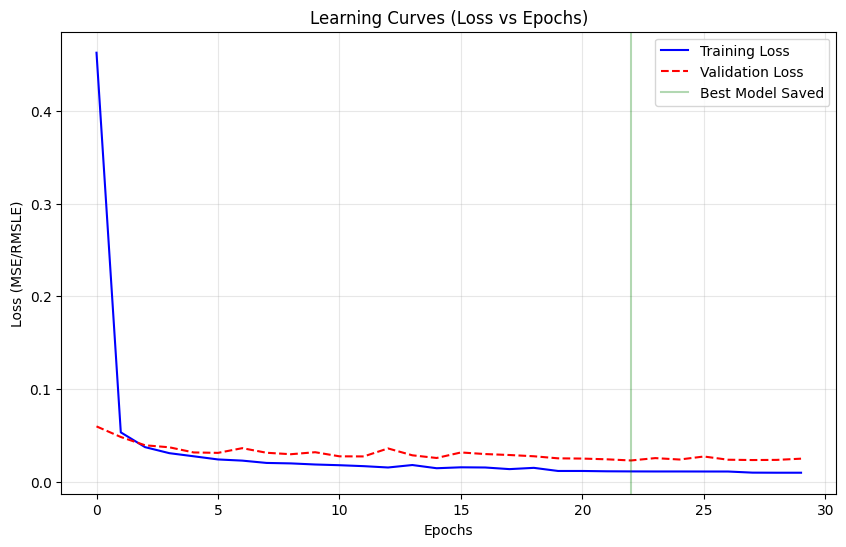

In [36]:
# ===== PLOT LEARNING CURVES =====
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# Use train_losses and val_losses defined in the training loop
plt.plot(train_losses, label='Training Loss', color='blue', linestyle='-')
plt.plot(val_losses, label='Validation Loss', color='red', linestyle='--')

# Mark the position of the lowest Val Loss to evaluate early stopping
min_val_loss_idx = val_losses.index(min(val_losses))
plt.axvline(x=min_val_loss_idx, color='green', alpha=0.3, label='Best Model Saved')

plt.title('Learning Curves (Loss vs Epochs)')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE/RMSLE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [37]:
# ===== SAVE LEARNING CURVE DATA =====
import pandas as pd
import os

# 1. Prepare data: store loss lists in a dictionary
history_data = {
    'epoch': range(1, len(train_losses) + 1),
    'train_loss': train_losses,
    'val_loss': val_losses
}

# 2. Convert to DataFrame
history_df = pd.DataFrame(history_data)

# 3. Set save path (reuse previous output directory)
output_path = '/content/drive/My Drive/IE7275/project/output'
if not os.path.exists(output_path):
    os.makedirs(output_path)

file_name = 'learning_curves_data.csv'
full_save_path = os.path.join(output_path, file_name)

# 4. Save to CSV
history_df.to_csv(full_save_path, index=False)

print(f"Learning curve data saved to:\n{full_save_path}")

Learning curve data saved to:
/content/drive/My Drive/IE7275/project/output/learning_curves_data.csv


In [38]:
import numpy as np
import pandas as pd
import torch
import os

# 1. Device setup and inference preparation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

all_preds = []
all_actuals = []

# Run model over val_loader, ensuring predictions and actuals are in the same order
with torch.no_grad():
    for b_num, b_cat, b_y in val_loader:
        b_num, b_cat = b_num.to(device), b_cat.to(device)
        preds = model(b_num, b_cat)
        all_preds.append(preds.detach().cpu().numpy())
        all_actuals.append(b_y.cpu().numpy())

# Concatenate results
y_pred_final = np.concatenate(all_preds).flatten()
y_true_final = np.concatenate(all_actuals).flatten()

# 2. Restore scale (Inverse Log Transform)
y_true_orig = np.expm1(y_true_final)
y_pred_orig = np.expm1(y_pred_final)
residuals = y_true_orig - y_pred_orig

# 3. Extract validation-period data for all stores
# Assumes validation set starts from 2017-08-01 (adjust to match your Step 4 split date)
val_start_date = '2017-08-01'

# Filter all store data after this date from the original train_df
# so that diagnostic_df includes data for all stores (1-54)
val_mask = train_df['date'] >= val_start_date
diagnostic_df = train_df[val_mask].copy()

# 4. Dimension alignment check
# If lengths differ, val_loader sample count does not match date-filtered rows
# (possibly because lag features cause row drops at the beginning)
if len(diagnostic_df) != len(residuals):
    print(f"Warning: length mismatch! DF rows ({len(diagnostic_df)}) != residuals ({len(residuals)})")
    # Mismatch usually means the model needs a history window, so early days cannot be predicted.
    # Trim diagnostic_df to match the length of residuals.
    diagnostic_df = diagnostic_df.iloc[-len(residuals):]

# Fill in computed results
diagnostic_df['actual_sales'] = y_true_orig
diagnostic_df['predicted_sales'] = y_pred_orig
diagnostic_df['residual'] = residuals
diagnostic_df['abs_residual'] = np.abs(residuals)

# 5. Export CSV
output_path = '/content/drive/My Drive/IE7275/project/output/tableau_full_diagnostic.csv'
diagnostic_df.to_csv(output_path, index=False)

print(f"Success! CSV contains data for all stores.")
print(f"Summary: data for {diagnostic_df['store_nbr'].nunique()} stores included.")

Success! CSV contains data for all stores.
Summary: data for 54 stores included.


In [40]:
# ===== EVALUATE ON VALIDATION SET =====
import torch
import numpy as np
from sklearn.metrics import mean_squared_log_error

# 1. Load model
model_path = '/content/drive/MyDrive/IE7275/project/best_transformer_model.pth'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = StoreTransformer(cat_limits, num_dim=num_dim)

# Load weights
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

# 2. Get predictions
all_preds = []
with torch.no_grad():
    # Use the previously defined val_loader
    for b_num, b_cat, _ in val_loader:
        b_num, b_cat = b_num.to(device), b_cat.to(device)
        outputs = model(b_num, b_cat)
        all_preds.append(outputs.cpu().numpy())

# Concatenate and inverse-transform log1p
y_pred_log = np.concatenate(all_preds).flatten()
y_pred_final = np.expm1(y_pred_log)
y_pred_final = np.maximum(0, y_pred_final) # Exclude negligible negative values

# 3. Align ground truth
# Important: val_loader predictions start from day 29 onwards
y_true_final = np.expm1(y_val.values)

# 4. Compute metrics
# Both predictions and actuals are now in the original sales scale
rmse = np.sqrt(mean_squared_log_error(y_true_final, y_pred_final))

print("=" * 40)
print("       MODEL PERFORMANCE SUMMARY       ")
print("=" * 40)
print(f"Metric: Root Mean Squared Error")
print(f"Validation RMSE: {rmse:.5f}")
print("-" * 40)

       MODEL PERFORMANCE SUMMARY       
Metric: Root Mean Squared Error
Validation RMSE: 0.15159
----------------------------------------


In [41]:
# ===== LOAD MODEL WEIGHTS =====
import torch
import numpy as np
import pandas as pd

# 1. Parameters must match those used during training exactly!
# Assumes cat_indices length is 18 and num_indices length is 15 during training.
# Make sure to use the same cat_limits variable from your training code.
model = StoreTransformer(cat_limits=cat_limits, num_dim=len(num_indices))

# 2. Load weights
model_path = '/content/drive/MyDrive/IE7275/project/best_transformer_model.pth'
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()
print("Model loaded successfully")

Model loaded successfully


In [42]:
# ===== INSTANTIATE AND LOAD BEST MODEL =====
# 1. Instantiate model
# Ensure num_indices length is 15 and cat_limits length is 18
model = StoreTransformer(
    cat_limits=cat_limits,
    num_dim=len(num_indices), # should be 15
    embed_dim=8,
    d_model=64
)

# Print to verify total input dimension is 159; loading weights will fail if it is not 159
print(f"Expected total model input dimension: {len(num_indices) + len(cat_limits)*8}")

# 2. Load weights
model_path = '/content/drive/MyDrive/IE7275/project/best_transformer_model.pth'
try:
    model.load_state_dict(torch.load(model_path, map_location=device))
    print("Weights loaded successfully! Ready to predict.")
except RuntimeError as e:
    print("Loading failed. Check that cat_limits length is 18 and num_indices length is 15.")
    print(e)

Expected total model input dimension: 135
Weights loaded successfully! Ready to predict.


In [43]:
# ===== BUILD TEST DATASET AND DATALOADER =====
test_dataset = TransformerDataset(
    X_test,                # Pass DataFrame directly; do not call .values()
    np.zeros(len(X_test)), # Labels are all zeros (placeholder)
    num_indices,
    cat_indices
)

test_loader = DataLoader(test_dataset, batch_size=2048, shuffle=False)

In [44]:
# ===== GENERATE TEST PREDICTIONS =====
import pandas as pd
import numpy as np

# 1. Verify current device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device) # Ensure model is on GPU
model.eval()

# 1. Get test set predictions
model.eval()
test_preds_log = []

with torch.no_grad():
    for b_num, b_cat, _ in test_loader:
        b_num, b_cat = b_num.to(device), b_cat.to(device)
        # Model output is log1p-transformed sales
        outputs = model(b_num, b_cat)
        test_preds_log.append(outputs.view(-1).cpu().numpy())

# Concatenate predictions from all batches
y_test_pred_log = np.concatenate(test_preds_log)

# 2. Inverse transform (expm1)
# Use expm1 to reverse log(x+1) back to original sales x
y_test_final = np.expm1(y_test_pred_log)

# Ensure no negative values (Kaggle does not accept negative sales)
y_test_final = np.maximum(0, y_test_final)

# 3. Create submission file
# Assumes test_id is already defined (extracted from the original test.csv id column)
submission = pd.DataFrame({
    'id': test_id,
    'sales': y_test_final
})

# 4. Export CSV
file_name = '/content/drive/My Drive/IE7275/project/submission_transformer_v3.csv'
submission.to_csv(file_name, index=False)

print(f"Success! File generated: {file_name}")
print(submission.head())

# Quick sanity check
print(f"\nPredicted sales mean: {submission['sales'].mean():.2f}")
print(f"Predicted sales max: {submission['sales'].max():.2f}")

Success! File generated: /content/drive/My Drive/IE7275/project/submission_transformer_v3.csv
           id     sales
1684  3000888  2.890404
1685  3002670  2.884181
1686  3004452  2.902980
1687  3006234  2.872331
1688  3008016  2.875782

Predicted sales mean: 433.20
Predicted sales max: 10805.12


In [45]:
# ===== ALTERNATIVE PREDICTION PASS =====
all_test_preds = []

with torch.no_grad():
    for b_num, b_cat, _ in test_loader:
        b_num, b_cat = b_num.to(device), b_cat.to(device)
        # Predictions are in log space
        preds = model(b_num, b_cat).view(-1)
        all_test_preds.append(preds.cpu().numpy())

# Concatenate all batches
y_test_pred_log = np.concatenate(all_test_preds)

# Core transformation
# 1. Reverse log transform to original sales: exp(x) - 1
final_sales = np.expm1(y_test_pred_log)

# 2. Ensure no negative values (expm1 rarely produces large negatives, but guard just in case)
final_sales = np.maximum(0, final_sales)

In [46]:
# ===== CREATE AND SAVE SUBMISSION FILE =====
# Assumes test_id was saved earlier or loaded from test.csv
# test_df = pd.read_csv('test.csv')

submission = pd.DataFrame({
    'id': test_id, # Ensure the number of ids matches final_sales
    'sales': final_sales
})

# Save file
submission.to_csv('submission_transformer_v3.csv', index=False)

print("Submission file generated!")
print(submission.head())

Submission file generated!
           id     sales
1684  3000888  2.890404
1685  3002670  2.884181
1686  3004452  2.902980
1687  3006234  2.872331
1688  3008016  2.875782
